In [1]:
"""
Debugging of the mutation factor estimating function 
"""

'\nDebugging of the mutation factor estimating function \n'

In [2]:
import numpy as np
import pickle 
import dpluspy 

In [3]:
# ARGUMENTS
chrom = 1
quartile = 0


# Define filepaths
vcf_file = f"../../data/vcf_files/merged/merged.variants.chr{chrom}.vcf.gz"
bed_file = f"data/bed_files/quartile_{quartile}/mask_chr{chrom}.bed.gz"
rec_map_file = f"../../data/recombination_maps/Bherer_b37/sexavg_chr{chrom}.txt"
# mut_map_file = f"../../data/mutation_maps/roulette_b37_1kb/roulette_1kb_chr{chrom}.csv.gz"
mut_map_file = f"../../data/mutation_maps/roulette_b37_16bit/roulette_b37_chr{chrom}.npy"
interval_file = f"../../data/intervals/chromosome_arms/arms_chr{chrom}.txt"
pop_file = "../../data/vcf_files/populations_sub"


# Define bins
bins = np.concatenate(([0], np.logspace(-7, -1, 25), 
    [1.77827941e-01, 3.16227766e-01, 4.99999e-01]))

In [4]:
stats = dpluspy.parsing.parse_stats(
    vcf_file,
    bed_file=bed_file,
    pop_file=pop_file,
    rec_map_file=rec_map_file,
    pos_col="pos",
    map_col="cM",
    r_bins=bins,
    mut_map_file=mut_map_file,
    interval_file=interval_file,
    chrom=chrom,
    overhang=None
)

[2025-07-11 09:11:53] Computed stats in chrom 1 interval 0
[2025-07-11 09:12:12] Computed stats in chrom 1 interval 1


In [5]:
stats[(1, 0)]["mut_facs"]

array([2.56000259e+09, 1.73540561e+09, 2.93308351e+09, 4.93245698e+09,
       8.19042888e+09, 1.33026355e+10, 2.04192357e+10, 2.98601820e+10,
       4.22921800e+10, 5.70261139e+10, 7.91758892e+10, 1.13906241e+11,
       1.55320180e+11, 2.08211919e+11, 2.68462429e+11, 3.71307628e+11,
       4.23422365e+11, 5.11620759e+11, 8.91301342e+11, 1.02682710e+12,
       1.47751972e+12, 2.25622461e+12, 4.19986063e+12, 7.30845715e+12,
       9.45983369e+12, 2.00886269e+13, 4.76929876e+13, 4.55710667e+13,
       1.68693453e+07])

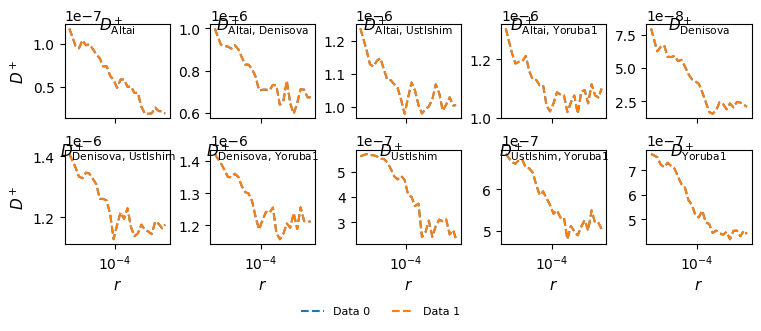

In [13]:
# Plot the result
reg = stats[(1, 1)]
pop_ids = reg["pop_ids"]
means = dpluspy.bootstrapping.weighted_means_across_regions(stats)
means1 = dpluspy.bootstrapping.weighted_means_across_regions(stats, aggregate=False)
varcovs = dpluspy.bootstrapping.compute_varcovs([means, means])
to_pops = ["Altai", "Denisova", "UstIshim", "Yoruba1"]
means = dpluspy.bootstrapping.subset_means(means, pop_ids, to_pops=to_pops)
means1 = dpluspy.bootstrapping.subset_means(means1, pop_ids, to_pops=to_pops)
varcovs = dpluspy.bootstrapping.subset_varcovs(varcovs, pop_ids, to_pops=to_pops)
dpluspy.plotting.plot_d_plus_curves(means=[means, means1], pop_ids=to_pops,
    bins=reg["bins"], varcovs=[varcovs, varcovs], ax_size=1.5, cols=5)

In [ ]:
# Reducing the disk space occupied by mut. maps
mutmap = np.load(mut_map_file).astype(np.float64)
print(np.min(mutmap[~np.isnan(mutmap)]))
print(np.max(mutmap[~np.isnan(mutmap)]))
print(np.nanmean(mutmap))
print(np.nanstd(mutmap))

0.1319580078125
74.375
1.1395655628325605
1.5575229826894406


In [ ]:
mutmap[~np.isnan(mutmap)]

array([0.51757812, 0.62402344, 0.51757812, ..., 0.46191406, 0.56835938,
       0.48217773], shape=(222244349,))